# CMFV V1
Better

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from dataclasses import dataclass

from cmfv import PressureTransducer, Servo, Valve, RAD_TO_DEG, DEG_TO_RAD, PController, CmfvSimInputs, CmfvSimInitialConditions, Controller, CmfvSimOutputs

### Sanity Check

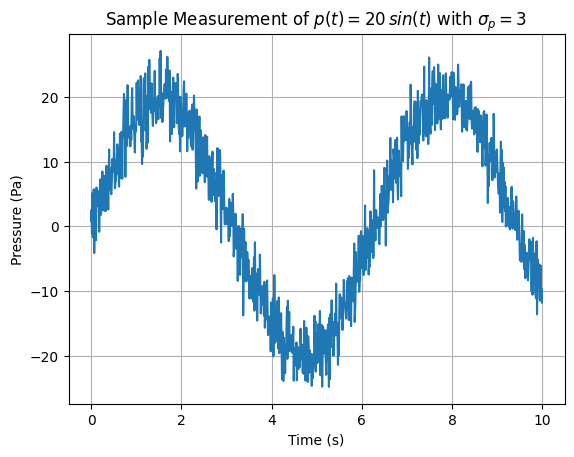

In [2]:
dt = 0.01
ts = np.arange(1000)*dt

sigma_p = 3 # Pa

ps = 20*np.sin(ts)
ducer = PressureTransducer(sigma_p, 0)
p_hat = [ducer.observe(p) for p in ps]

plt.title(rf"Sample Measurement of $p(t) = 20\,sin(t)$ with $\sigma_p = {sigma_p}$")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (Pa)")
plt.plot(ts, p_hat )
plt.grid()
plt.show()

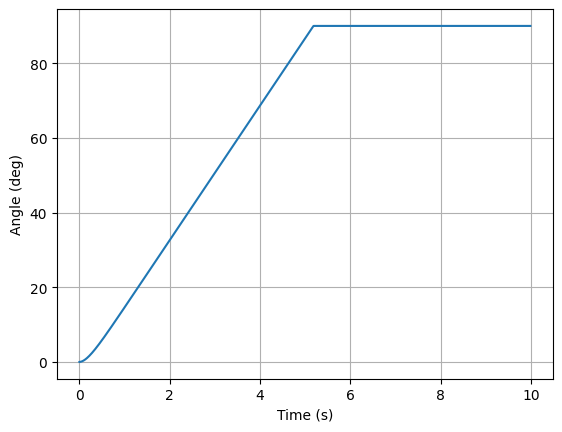

In [3]:
dt = 0.01
angles = np.linspace(0, np.pi, 1000)
servo_Kp = 5
servo = Servo(dt, servo_Kp)

# ducer = PressureTransducer(sigma_p, 0)
theta = np.array([servo.step(a) for a in angles])

# title = rf"Integrating Valve angle at {theta_dot} deg/s with $\sigma = {sigma_angle} deg/s$"
# plt.title(title)
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.plot(ts, theta * RAD_TO_DEG)
plt.grid()
plt.show()

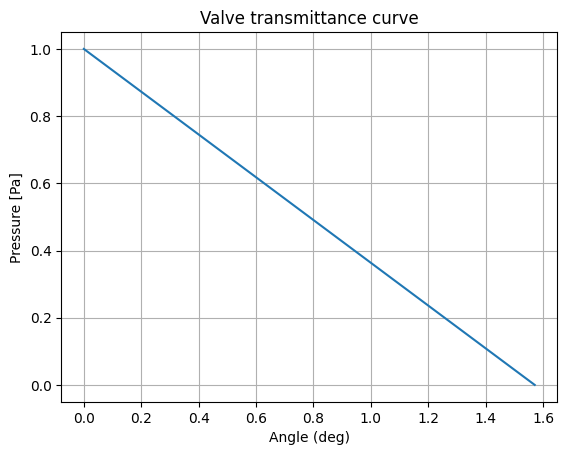

In [4]:
p1 = 1
v1 = 12
angles = np.linspace(0, 90*DEG_TO_RAD, 1000)
v = Valve()
ps = [v.across(p1, v1, angle) for angle in angles]


title = "Valve transmittance curve"
plt.title(title)
plt.plot(angles, ps)
plt.ylabel("Pressure [Pa]")
plt.xlabel("Angle (deg)")
plt.grid()
plt.show()

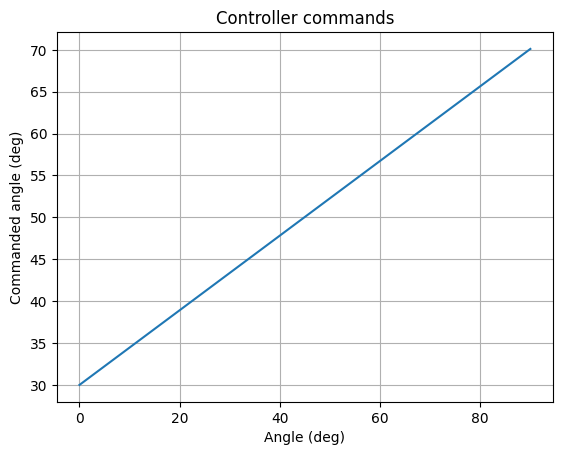

In [5]:
# Should command further angles based on pressure difference

p_act = 7e6

p_dess = np.linspace(p_act, 0, 1000)

Kp = 1e-7
controller = PController(Kp)


cmds = np.array([controller.control(p_des, p_act, 30*DEG_TO_RAD) for p_des in p_dess])

    # theta_cmds[i+1] = controller.control(p_setpoint, p_meas[i], angle)

title = "Controller commands"
plt.title(title)
plt.plot(angles * RAD_TO_DEG, cmds * RAD_TO_DEG)
plt.ylabel("Commanded angle (deg)")
plt.xlabel("Angle (deg)")
plt.grid()
plt.show()

## Combined test

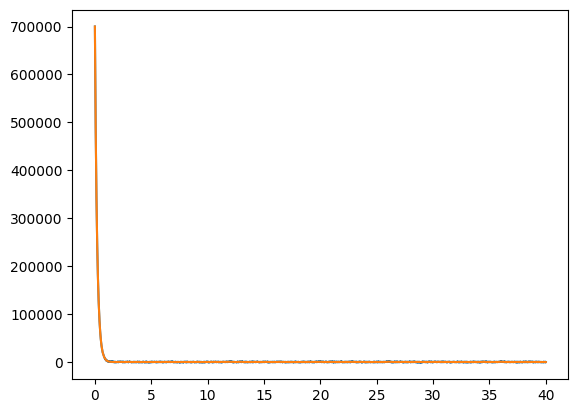

In [6]:
## Combined test

np.random.seed(173)

dt = 0.01
nsteps = 4000

# ----- In order of blocks -----
sigma_angle = 0.01 * DEG_TO_RAD # deg
servo_Kp = 5
theta0 = 0 * DEG_TO_RAD
theta_cmd = 90 * DEG_TO_RAD
servo = Servo(dt, servo_Kp, theta0, sigma_angle)

valve = Valve()

sigma_p = 300 # Pa
ducer = PressureTransducer(sigma_p, 0)

# ----- ICs -----
p_tank = 700_000 # Pa
v1 = 0.01 # m/s

# ----- Setup -----

ts = np.arange(nsteps+1)*dt

angles = np.zeros((nsteps+1))
ps = np.zeros((nsteps+1))
p_meas = np.zeros((nsteps+1))
angles[0] = theta0
ps[0] = valve.across(p_tank, 0, theta0)
p_meas[0] = ducer.observe(ps[0])

for i in range(nsteps):

    angle = servo.step(theta_cmd)

    v = 0
    p = valve.across(p_tank, v, angle)

    angles[i+1] = angle
    ps[i+1] = p
    p_meas[i+1] = ducer.observe(p)
    


# plt.plot(ts, angles * RAD_TO_DEG)
plt.plot(ts, p_meas)
plt.plot(ts, ps)
plt.show()

# ducer = PressureTransducer(sigma_p, 0)
# theta = [angle.step(theta_dot) for _ in ts]

### Controller part

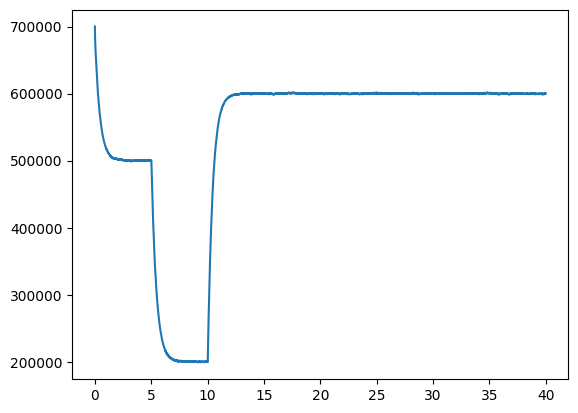

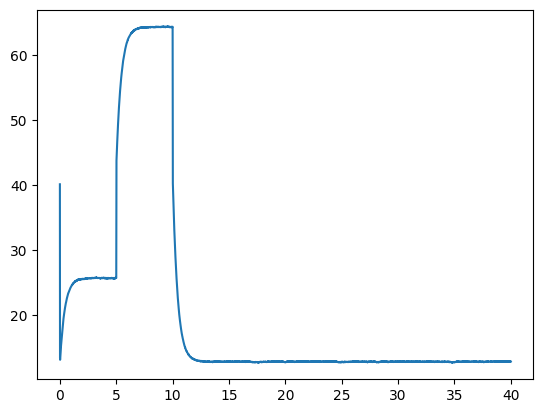

In [7]:
# dt = 0.01
# nsteps = 2000



# p_tank = 7e6 # Pa
# v1 = 0.01 # m/s

# # ----- Setup -----

# sigma_angle = 0.01 * DEG_TO_RAD # deg
# servo_Kp = 5
# theta0 = 0 * DEG_TO_RAD
# theta_cmd = 90 * DEG_TO_RAD
# servo = Servo(dt, servo_Kp, theta0, sigma_angle)

# ts = np.arange(nsteps+1)*dt

# angles = np.zeros((nsteps+1))
# ps = np.zeros((nsteps+1))
# p_meas = np.zeros((nsteps+1))


# ps[0] = p_tank

# # angle = 90
# # ps[0] = 0

# angles[0] = theta0
# p_meas[0] = ducer.observe(ps[0])



Kp = 1e-6
controller = PController(Kp)
p_setpoint = 0

theta_cmds = np.zeros((nsteps+1))
theta_cmds[0] = controller.control(p_setpoint, p_meas[0], theta0)

servo.theta = 0
servo.omega = 0
for i in range(nsteps):

    if ts[i] < 5:
        p_setpoint = 5e5
    elif ts[i] < 10:
        p_setpoint = 2e5
    elif ts[i] < 15:
        p_setpoint = 6e5

    angle = servo.step(theta_cmds[i])
    
    # v = p_tank - p # idk causal?
    # v = np.sqrt(2*(p_tank - ps[i]))
    v = v1
    p = valve.across(p_tank, v, angle)

    angles[i+1] = angle
    ps[i+1] = p
    p_meas[i+1] = ducer.observe(p)
    theta_cmds[i+1] = controller.control(p_setpoint, p_meas[i], angle)


# plt.plot(ts, angles * RAD_TO_DEG)
plt.plot(ts, p_meas)
# plt.plot(ts, ps)
plt.show()

plt.plot(ts, theta_cmds * RAD_TO_DEG)
plt.show()


### Gettin that sim on

In [8]:
def run_sim(sim_in: CmfvSimInputs, ICs: CmfvSimInitialConditions, controller: Controller, p_r_func: Callable[[float], float]) -> CmfvSimOutputs:
    
    if sim_in.seed is not None:
        np.random.seed(sim_in.seed) 

    servo = Servo(sim_in.dt, sim_in.servo_KP, ICs.theta, sim_in.sigma_angle)
    valve = Valve(rho=1, A=1)
    
    p_out0 = valve.across(ICs.p_tank, ICs.v, ICs.theta) # Initial pressure on other side
    ducer = PressureTransducer(sim_in.sigma_p, p_out0)

    N = sim_in.nsteps
    dt = sim_in.dt

    ts = np.arange(N+1)*dt

    angles = np.zeros((N+1))
    p_truth = np.zeros((N+1))
    p_meas = np.zeros((N+1))
    p_setpoints = np.zeros((N+1))
    theta_cmd = np.zeros((N+1))

    angles[0] = ICs.theta
    p_truth[0] = p_out0

    p_meas[0] = ducer.observe(p_truth[0])
    p_setpoints[0] = p_r_func(ts[0])
    theta_cmd[0] = controller.control(p_setpoints[0], p_meas[0], ICs.theta)

    for i in range(N):

        # Advance angle according to command
        angle = servo.step(theta_cmd[i])
        
        # Just having velocity equal to starting one 
        v = ICs.v
        p_downstream = valve.across(ICs.p_tank, v, angle)

        angles[i+1] = angle
        p_truth[i+1] = p_downstream
        p_meas[i+1] = ducer.observe(p_downstream)

        # Get setpoint for the current step
        p_setpoints[i+1] = p_r_func(ts[i])
        theta_cmd[i+1] = controller.control(p_setpoints[i+1], p_meas[i+1], angle)

    return CmfvSimOutputs(
        time = ts,
        theta = angles,
        p_truth = p_truth,
        theta_cmd = theta_cmd,
        p_meas = p_meas,
        p_setpoint = p_setpoints
    )
    


In [9]:
def plot_sim(out: CmfvSimOutputs, start = 0, stop = -1, figsize = (12,8)):
    
    # Plot for pressure vs. setpoint
    plt.figure(figsize=figsize)
    # plt.
    # plt.subplot(3, 1, 1)
    plt.title("Pressure vs. Setpoint")
    plt.plot(out.time[start:stop], out.p_setpoint[start:stop], label="Setpoint", linestyle="-.", color="r")
    plt.plot(out.time[start:stop], out.p_meas[start:stop], label="Measured pressure", color="tab:orange")
    plt.plot(out.time[start:stop], out.p_truth[start:stop], label="Pressure", color="tab:blue")
    plt.legend()
    plt.xlabel("Time [s]")
    plt.ylabel("Pressure [Pa]")
    plt.show()

    # Plot for angle vs. time
    plt.figure(figsize=figsize)
    plt.title("Valve angle")
    plt.plot(out.time[start:stop], out.theta[start:stop] * RAD_TO_DEG, label="Valve Angle")
    plt.plot(out.time[start:stop], out.theta_cmd[start:stop] * RAD_TO_DEG, label="Angle command",
             linestyle="-.", color="r", alpha = 0.5)
    plt.legend()
    plt.xlabel("Time [s]")
    plt.ylabel("Angle [deg]")
    plt.show()

    # # Plot for angle_dot vs. time
    # plt.figure(figsize=figsize)
    # plt.title("Valve angle command")
    # plt.xlabel("Time [s]")
    # plt.ylabel("Command [deg]")
    # plt.show()


## Preliminary Runs

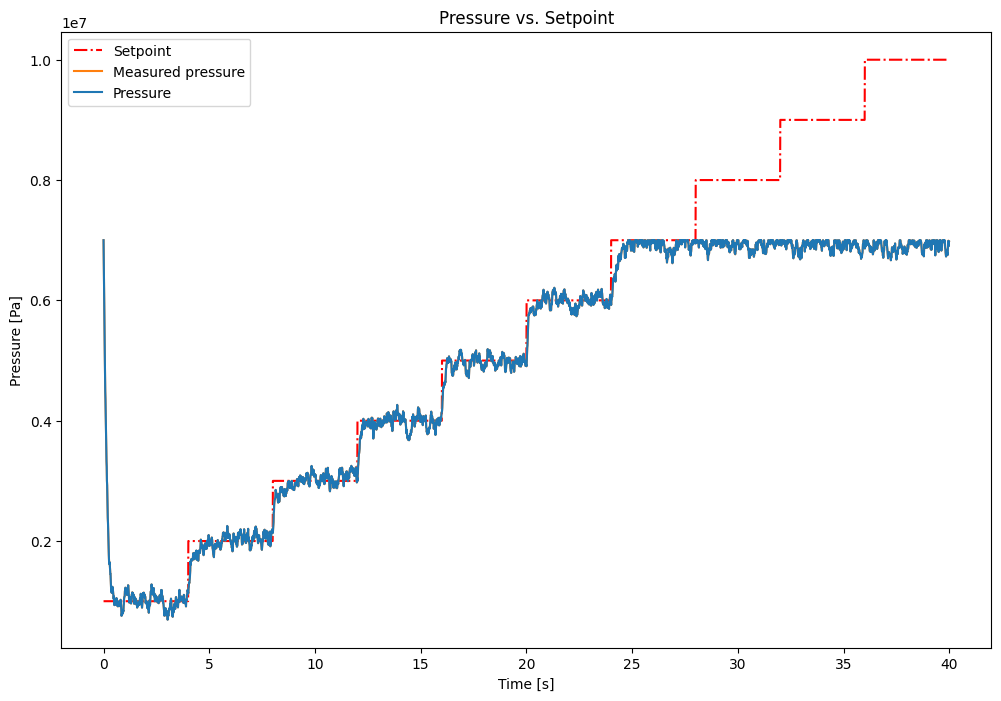

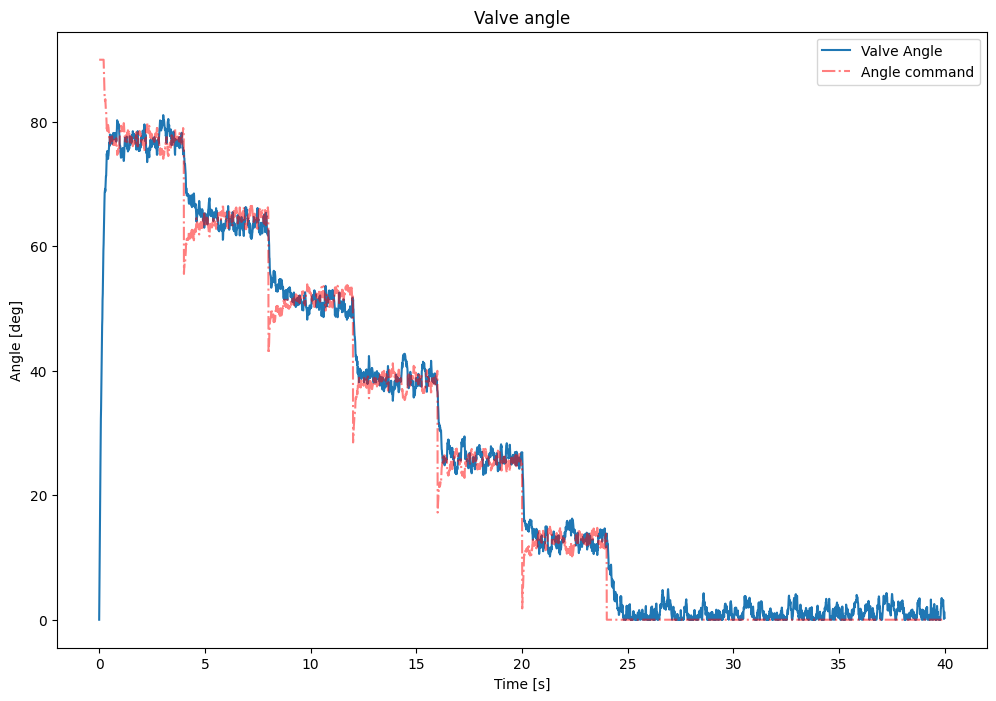

In [17]:
sim_in = CmfvSimInputs(
    dt = 0.01,
    nsteps = 4000,
    sigma_angle = 0.01, # deg/s
    sigma_p = 1000, # Pa
    # seed = 173
)

sim_ICs = CmfvSimInitialConditions(
    p_tank = 7e6, # Pa
    v = 1, # m/s
    theta = 0
)

def setpoint(t):
    return np.floor(t/4) * 1e6 + 1e6

Kp = 4e-7
controller = PController(Kp)

sim_out = run_sim(sim_in, sim_ICs, controller, setpoint)

start = 0
stop = -1

plot_sim(sim_out, start=start, stop=stop)

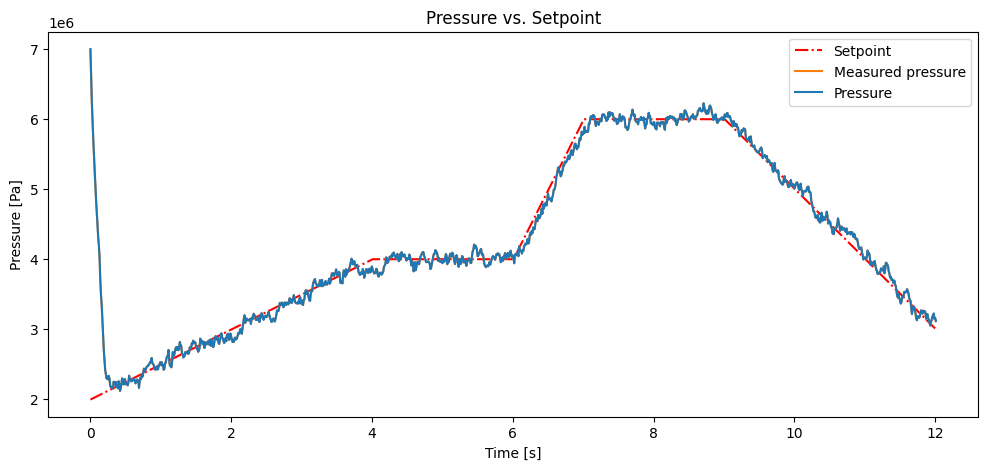

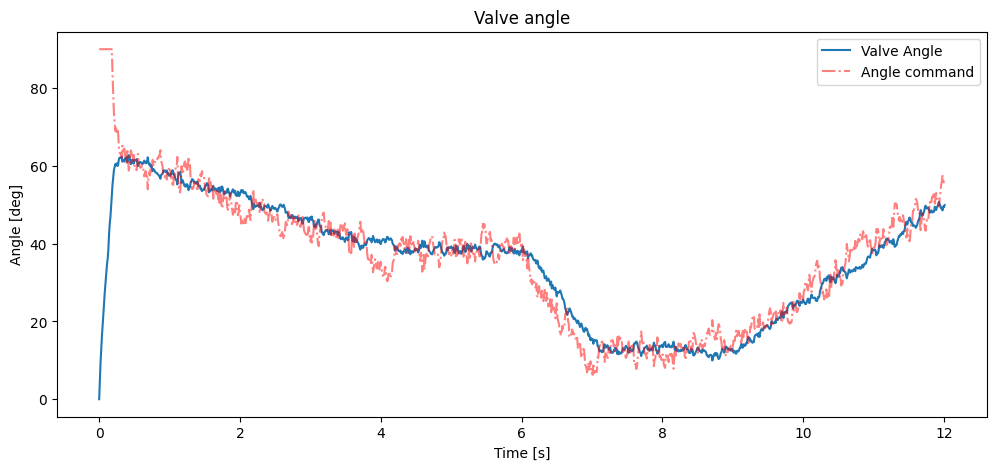

In [21]:
# This is where we need to turn to different types of controllers
def rampish(t):
    """(0, 3e6)--> (4, 4e6) then (6, 4e6)--> (7, 6e6) then (9, 6e6)--> (12, 3e6) then 3e6"""
    if t < 4:
        return 2e6*t/4 + 2e6
    elif t < 6:
        return 4e6
    elif t < 7:
        return 2e6*(t-6) + 4e6
    elif t < 9:
        return 6e6
    elif t < 12:
        return -1e6*(t-9) + 6e6

Kp = 8e-7
controller = PController(Kp)

sim_out = run_sim(sim_in, sim_ICs, controller, rampish)

start = 0
stop = -1

plot_sim(sim_out, start=start, stop=stop, figsize=(12,5))